In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

In [3]:
# 1. Buscar los archivos subidos en la carpeta por defecto de Colab
archivos_csv = glob.glob('data/harth/*.csv')
# Filtramos asegurando que el nombre empiece con 's' o 'S'
archivos_sujetos = [f for f in archivos_csv if os.path.basename(f).lower().startswith('s')]

print(f"✅ Se encontraron {len(archivos_sujetos)} archivos de sujetos.")

✅ Se encontraron 22 archivos de sujetos.


In [4]:
# 2. Cargar los datos en el diccionario para la validación LOSO
dataset_dict = {}
for archivo in archivos_sujetos:
    # Extraer el ID, ej: 's022.csv' -> 'S022'
    sujeto_id = os.path.basename(archivo).split('.')[0].upper()
    df = pd.read_csv(archivo)
    dataset_dict[sujeto_id] = df

if len(dataset_dict) > 0:
    print(f"✅ Datos cargados correctamente: {list(dataset_dict.keys())[:5]}...\n")

✅ Datos cargados correctamente: ['S006', 'S008', 'S009', 'S010', 'S012']...



✅ Datos cargados correctamente: ['S006', 'S008', 'S009', 'S010', 'S012']...



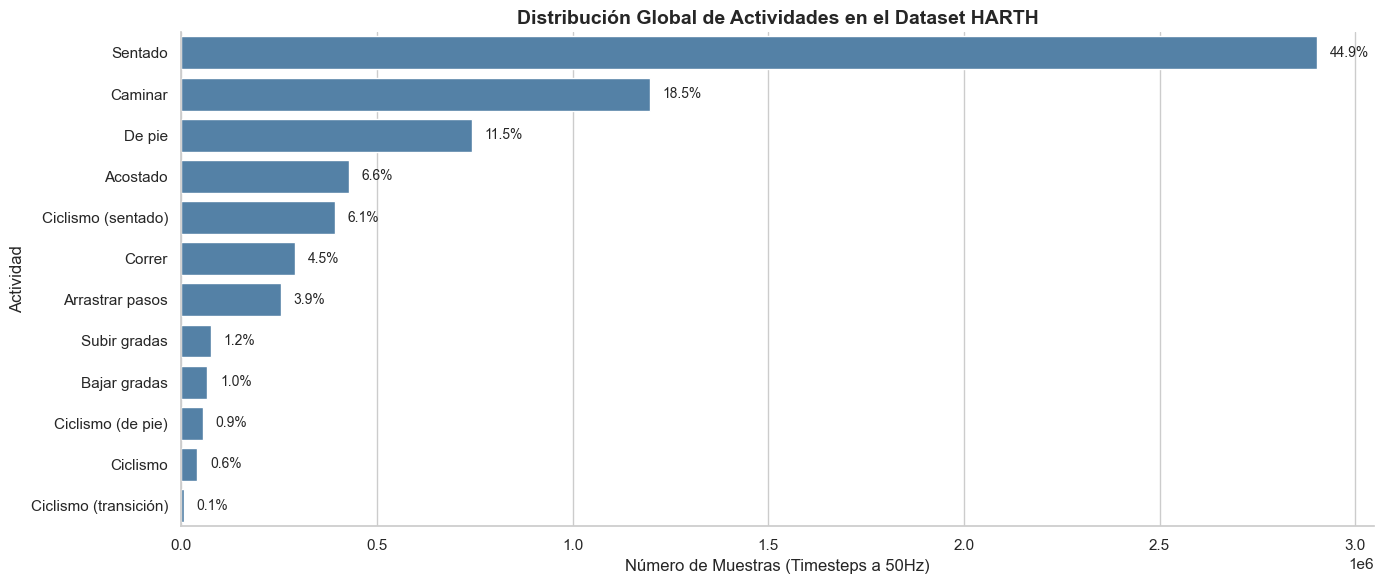

In [5]:
if len(dataset_dict) > 0:
    print(f"✅ Datos cargados correctamente: {list(dataset_dict.keys())[:5]}...\n")

    # 3. Unir temporalmente para el EDA Global
    df_global = pd.concat(dataset_dict.values(), ignore_index=True)

    # 4. Diccionario de las 12 actividades (según paper original de HARTH)
    nombres_clases = {
        1: 'Caminar', 2: 'Correr', 3: 'Arrastrar pasos', 4: 'Subir gradas',
        5: 'Bajar gradas', 6: 'De pie', 7: 'Sentado', 8: 'Acostado',
        13: 'Ciclismo (sentado)', 14: 'Ciclismo (de pie)',
        130: 'Ciclismo', 140: 'Ciclismo (transición)'
    }

    df_global['Actividad'] = df_global['label'].map(nombres_clases)

    # 5. Generar la gráfica
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 6))

    # Contar los valores para ordenar la gráfica de mayor a menor
    conteo = df_global['Actividad'].value_counts()

    ax = sns.countplot(data=df_global, y='Actividad',
                       order=conteo.index,
                       color='steelblue')

    plt.title("Distribución Global de Actividades en el Dataset HARTH", fontsize=14, fontweight='bold')
    plt.xlabel("Número de Muestras (Timesteps a 50Hz)", fontsize=12)
    plt.ylabel("Actividad", fontsize=12)

    # Añadir porcentajes a las barras
    total = len(df_global)
    for p in ax.patches:
        porcentaje = f'{100 * p.get_width() / total:.1f}%'
        x = p.get_x() + p.get_width() + (total * 0.005)
        y = p.get_y() + p.get_height() / 2
        ax.annotate(porcentaje, (x, y), va='center', fontsize=10)

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("❌ No se pudieron cargar los datos.")

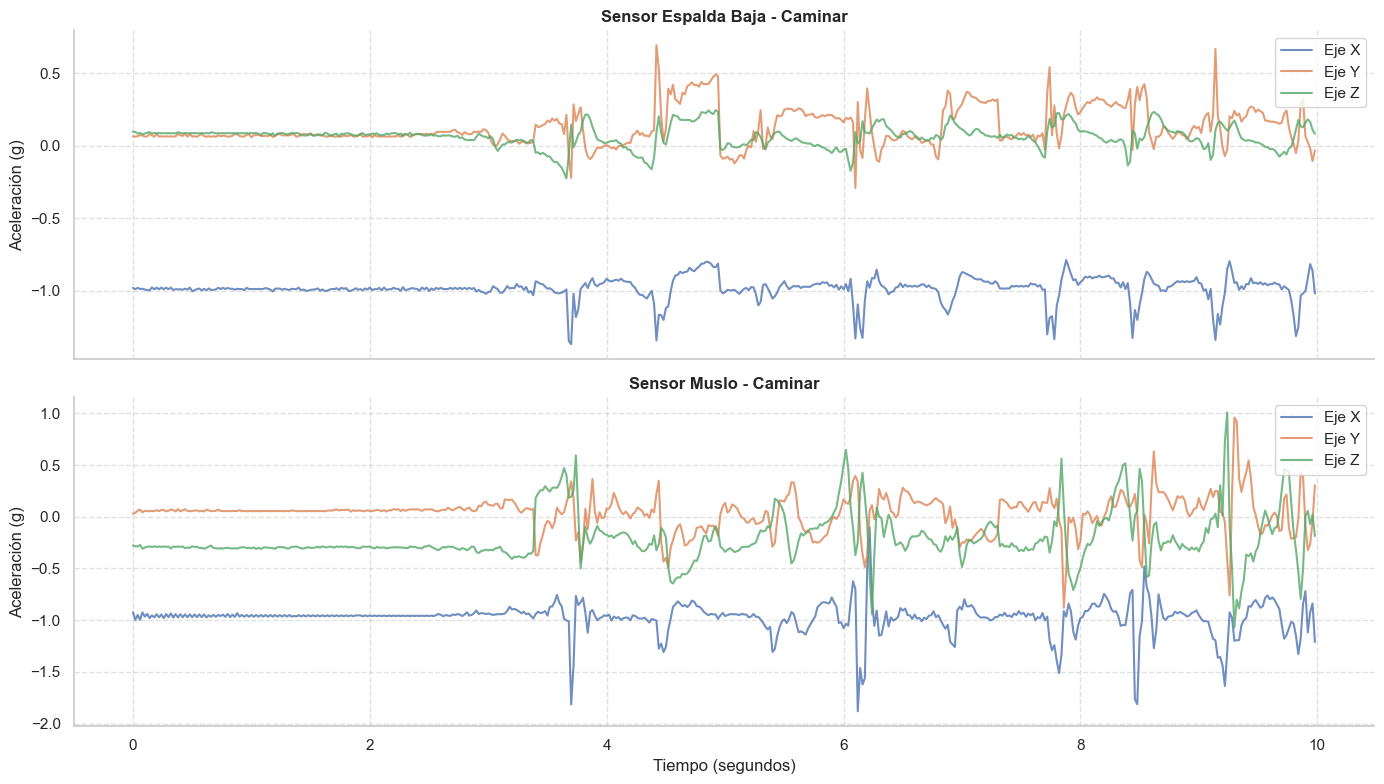

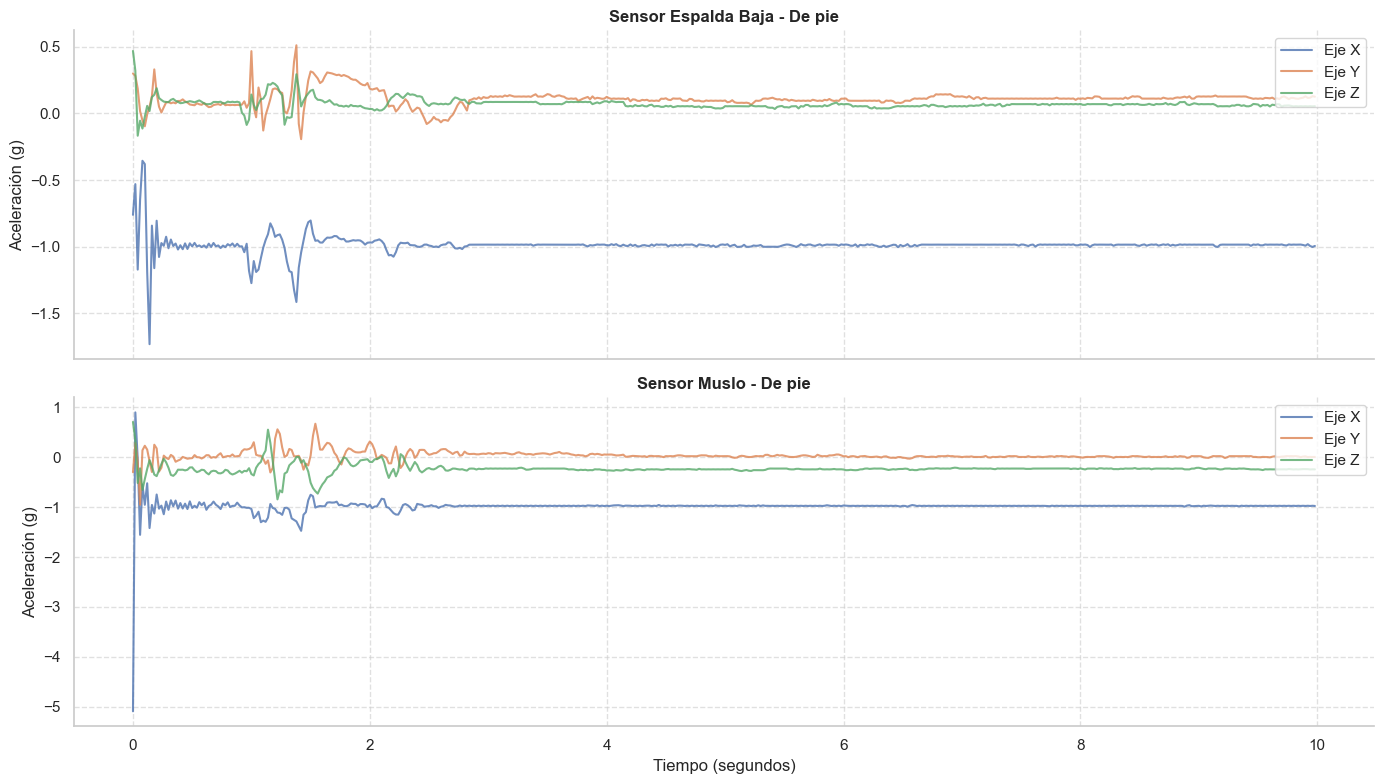

In [6]:
# Tomaremos un sujeto al azar para la visualización, por ejemplo el primero de la lista
sujeto_ejemplo = list(dataset_dict.keys())[0]
df_ejemplo = dataset_dict[sujeto_ejemplo]

def graficar_senales(df, actividad_num, nombre_actividad, duracion_segundos=10, hz=50):
    """
    Grafica una ventana de tiempo de las señales de ambos sensores para una actividad específica.
    """
    # Filtrar por la actividad solicitada
    df_actividad = df[df['label'] == actividad_num].reset_index(drop=True)

    if df_actividad.empty:
        print(f"El sujeto {sujeto_ejemplo} no tiene registros de la actividad: {nombre_actividad}")
        return

    # Limitar la cantidad de datos a mostrar (ej. 10 segundos = 500 timesteps)
    muestras = duracion_segundos * hz
    df_plot = df_actividad.iloc[:muestras]

    # Crear la figura con 2 subgráficos (uno para cada sensor)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Crear un eje X en segundos
    tiempo = np.arange(len(df_plot)) / hz

    # Sensor 1: Espalda Baja (Back)
    ax1.plot(tiempo, df_plot['back_x'], label='Eje X', alpha=0.8)
    ax1.plot(tiempo, df_plot['back_y'], label='Eje Y', alpha=0.8)
    ax1.plot(tiempo, df_plot['back_z'], label='Eje Z', alpha=0.8)
    ax1.set_title(f'Sensor Espalda Baja - {nombre_actividad}', fontweight='bold')
    ax1.set_ylabel('Aceleración (g)')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Sensor 2: Muslo (Thigh)
    ax2.plot(tiempo, df_plot['thigh_x'], label='Eje X', alpha=0.8)
    ax2.plot(tiempo, df_plot['thigh_y'], label='Eje Y', alpha=0.8)
    ax2.plot(tiempo, df_plot['thigh_z'], label='Eje Z', alpha=0.8)
    ax2.set_title(f'Sensor Muslo - {nombre_actividad}', fontweight='bold')
    ax2.set_ylabel('Aceleración (g)')
    ax2.set_xlabel('Tiempo (segundos)')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    sns.despine()
    plt.tight_layout()
    plt.show()

# Graficar 10 segundos de "Caminar" (Etiqueta 1)
graficar_senales(df_ejemplo, actividad_num=1, nombre_actividad="Caminar")

# Graficar 10 segundos de "De pie" (Etiqueta 6) para contrastar
graficar_senales(df_ejemplo, actividad_num=6, nombre_actividad="De pie")

In [8]:
from scipy import stats
import numpy as np

def crear_ventanas_deslizantes(df, window_size=150, step_size=75):
    """
    Transforma un DataFrame continuo en ventanas deslizantes.

    Parámetros:
    - df: DataFrame del sujeto con columnas de sensores y 'label'.
    - window_size: Tamaño de la ventana (150 = 3 segundos a 50Hz).
    - step_size: Avance de la ventana (75 = 50% de solapamiento).

    Retorna:
    - X: Array 3D con forma (num_ventanas, canales, tamaño_ventana).
    - y: Array 1D con las etiquetas de cada ventana.
    """
    # Extraer solo las columnas de los sensores (ignoramos 'timestamp' y 'label')
    # Columnas: back_x, back_y, back_z, thigh_x, thigh_y, thigh_z
    columnas_sensores = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

    valores_sensores = df[columnas_sensores].values
    etiquetas = df['label'].values

    ventanas_X = []
    ventanas_y = []

    # Recorrer los datos dando "saltos" según el step_size
    for i in range(0, len(df) - window_size, step_size):
        # 1. Extraer la ventana de características
        ventana_x = valores_sensores[i : i + window_size]

        # 2. Extraer las etiquetas de esa ventana
        ventana_y_temp = etiquetas[i : i + window_size]

        # 3. Asignar etiqueta por mayoría (Moda) dentro de la ventana (como pide tu perfil)
        # stats.mode devuelve la moda y su conteo. Tomamos el primer valor.
        etiqueta_mayoritaria = stats.mode(ventana_y_temp, keepdims=True)[0][0]

        # Guardar
        ventanas_X.append(ventana_x)
        ventanas_y.append(etiqueta_mayoritaria)

    # Convertir listas a arrays de NumPy
    X_arr = np.array(ventanas_X)
    y_arr = np.array(ventanas_y)

    # Transponer X para PyTorch: PyTorch CNN1D espera (batch, channels, sequence_length)
    # Originalmente es (num_ventanas, 150, 6). Lo cambiamos a (num_ventanas, 6, 150)
    X_arr = np.transpose(X_arr, (0, 2, 1))

    return X_arr, y_arr

# --- PRUEBA DE LA FUNCIÓN ---
# Vamos a probar la función con el primer sujeto de tu diccionario
sujeto_prueba = list(dataset_dict.keys())[0]
df_prueba = dataset_dict[sujeto_prueba]

print(f"Procesando al sujeto {sujeto_prueba}...")
X_prueba, y_prueba = crear_ventanas_deslizantes(df_prueba, window_size=150, step_size=75)

print("\n✅ Transformación completada:")
print(f"Forma original del DataFrame: {df_prueba.shape}")
print(f"Forma de X (Tensores de Entrada): {X_prueba.shape} -> (Ventanas, Canales, Timesteps)")
print(f"Forma de y (Etiquetas): {y_prueba.shape}")

Procesando al sujeto S006...

✅ Transformación completada:
Forma original del DataFrame: (408709, 8)
Forma de X (Tensores de Entrada): (5448, 6, 150) -> (Ventanas, Canales, Timesteps)
Forma de y (Etiquetas): (5448,)


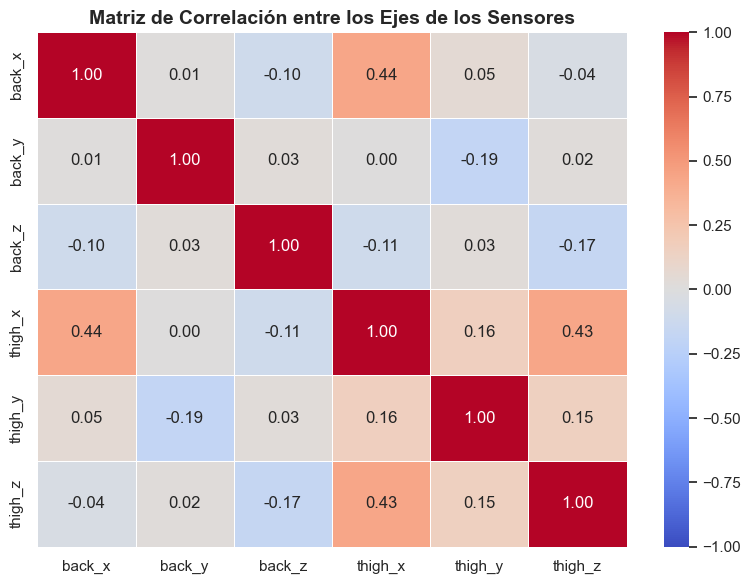

In [9]:
# 1. Matriz de Correlación de los Sensores
columnas_sensores = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

plt.figure(figsize=(8, 6))
# Calculamos la correlación de Pearson entre todos los ejes
matriz_corr = df_global[columnas_sensores].corr()

# Graficamos el mapa de calor (Heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlación entre los Ejes de los Sensores", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

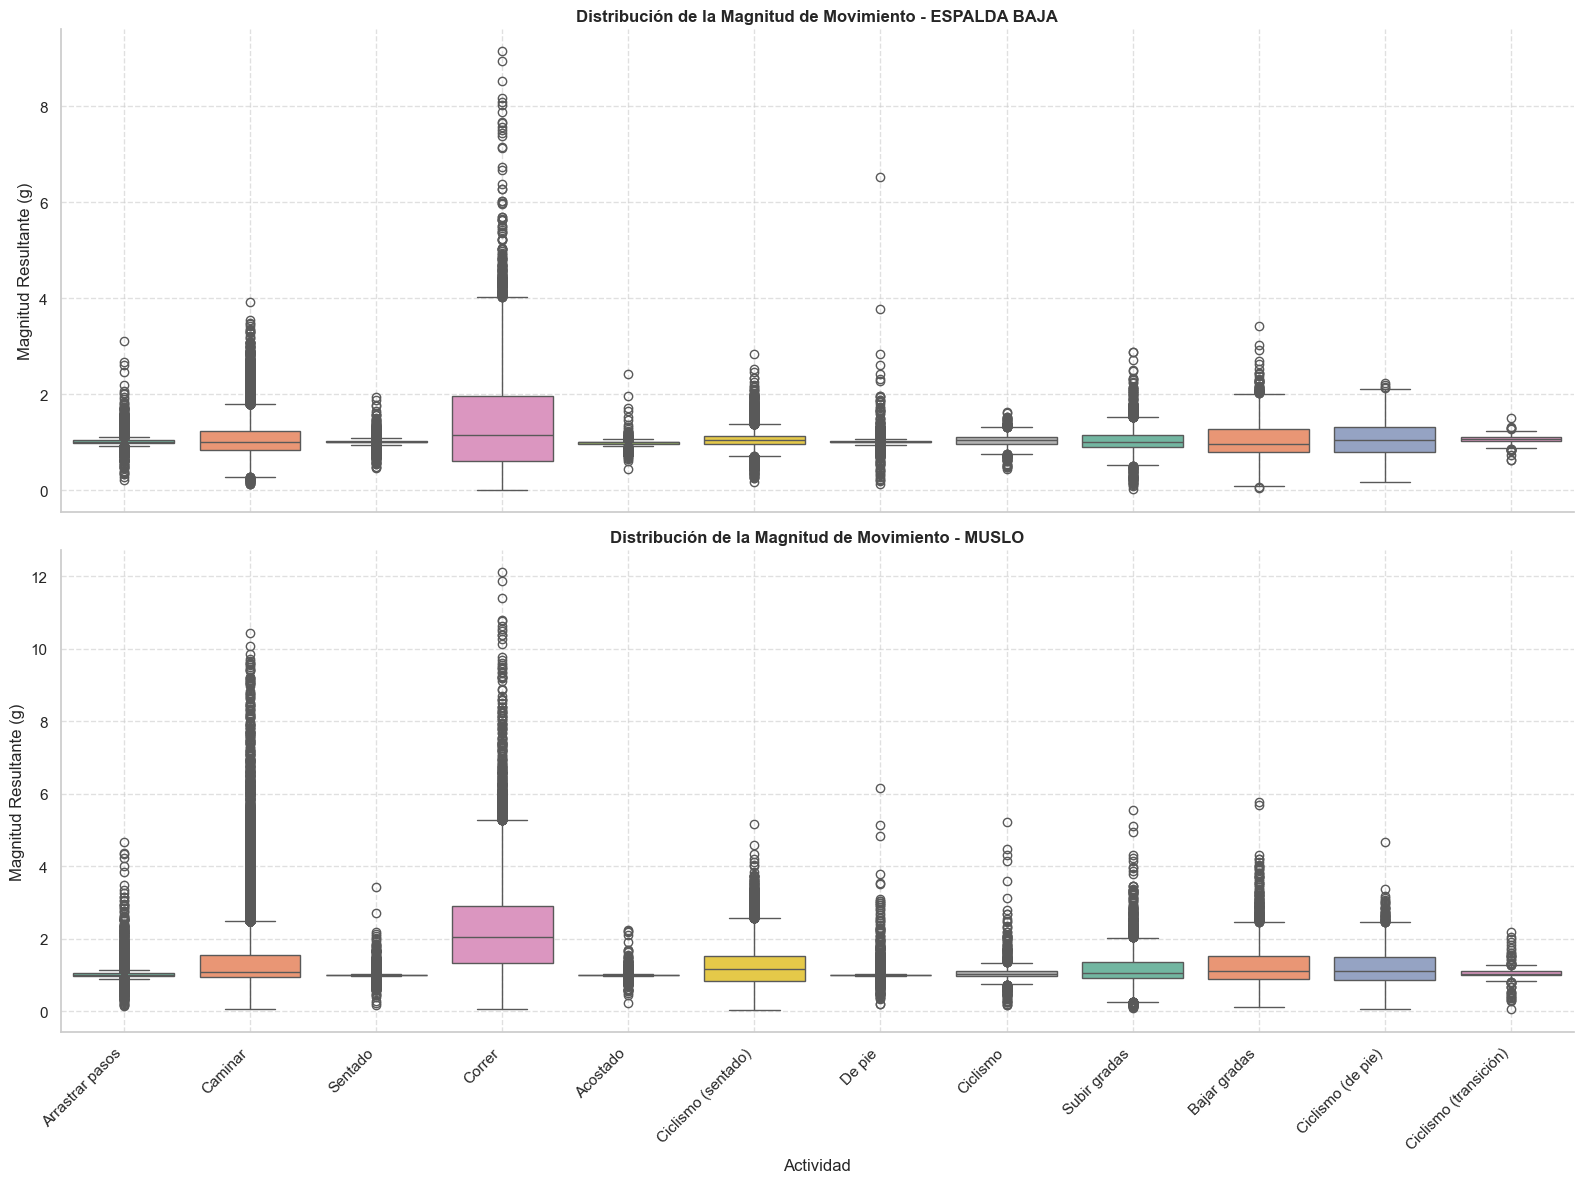

In [10]:
# 2. Magnitud de la Aceleración por Actividad
# Calculamos la magnitud matemática del vector 3D para cada sensor
df_global['back_mag'] = np.sqrt(df_global['back_x']**2 + df_global['back_y']**2 + df_global['back_z']**2)
df_global['thigh_mag'] = np.sqrt(df_global['thigh_x']**2 + df_global['thigh_y']**2 + df_global['thigh_z']**2)

# Para evitar saturar la RAM de Colab con millones de puntos en el gráfico,
# tomamos una muestra representativa del 5% de los datos
df_sample = df_global.sample(frac=0.05, random_state=42)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Boxplot para el sensor de la Espalda
sns.boxplot(x='Actividad', y='back_mag', data=df_sample, ax=ax1, palette='Set2', hue='Actividad', legend=False)
ax1.set_title("Distribución de la Magnitud de Movimiento - ESPALDA BAJA", fontweight='bold')
ax1.set_ylabel("Magnitud Resultante (g)")
ax1.grid(True, linestyle='--', alpha=0.6)

# Boxplot para el sensor del Muslo
sns.boxplot(x='Actividad', y='thigh_mag', data=df_sample, ax=ax2, palette='Set2', hue='Actividad', legend=False)
ax2.set_title("Distribución de la Magnitud de Movimiento - MUSLO", fontweight='bold')
ax2.set_ylabel("Magnitud Resultante (g)")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

In [1]:
import torch
print(torch.version.cuda)        # Debe mostrar la versión CUDA
print(torch.cuda.is_available()) # Debe ser True
print(torch.cuda.get_device_name(0))  # "NVIDIA GeForce RTX 3070"

11.8
True
NVIDIA GeForce RTX 3070
